In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/My Drive/FinalYearProject/RetinalDieaseFYP/small_aptos

/content/drive/My Drive/FinalYearProject/RetinalDieaseFYP/small_aptos


In [ ]:
import os, pandas as pd

SOURCE_DIR = '/content/drive/My Drive/FinalYearProject/RetinalDieaseFYP/small_aptos/train_images'
LABELS_FILE = '/content/drive/My Drive/FinalYearProject/RetinalDieaseFYP/small_aptos/train.csv'

print("Images folder exists:", os.path.exists(SOURCE_DIR))
print("CSV file exists:", os.path.exists(LABELS_FILE))

labels = pd.read_csv(LABELS_FILE)
print("\n CSV loaded successfully! Rows:", len(labels))
print(labels.head())

print("\n Number of images found:", len(os.listdir(SOURCE_DIR)))
print("Sample filenames:", os.listdir(SOURCE_DIR)[:5])


Images folder exists: True
CSV file exists: True

 CSV loaded successfully! Rows: 3662
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0

 Number of images found: 2293
Sample filenames: ['d83c3efade75.png', 'd85ea1220a03.png', 'd881c04f01fe.png', 'd7e5fe5245e0.png', 'edceb0657d77.png']


In [ ]:
import shutil
import glob

DEST_DIR = '/content/drive/My Drive/FinalYearProject/RetinalDieaseFYP/aptos2019_sorted'

# Create destination folders
os.makedirs(os.path.join(DEST_DIR, 'healthy'), exist_ok=True)
os.makedirs(os.path.join(DEST_DIR, 'unhealthy'), exist_ok=True)

# Build dictionary of available images
all_images = {}
for ext in ['png', 'jpg', 'jpeg']:
    for path in glob.glob(os.path.join(SOURCE_DIR, f'*.{ext}')):
        file_id = os.path.splitext(os.path.basename(path))[0].lower()
        all_images[file_id] = path

# Copy based on diagnosis
healthy_count, unhealthy_count = 0, 0
for _, row in labels.iterrows():
    img_id = str(row['id_code']).lower()
    label = row['diagnosis']
    if img_id in all_images:
        src = all_images[img_id]
        dest_subfolder = 'healthy' if label == 0 else 'unhealthy'
        shutil.copy(src, os.path.join(DEST_DIR, dest_subfolder, os.path.basename(src)))
        if label == 0:
            healthy_count += 1
        else:
            unhealthy_count += 1

print("Sorting complete!")
print(f"Healthy images copied: {healthy_count}")
print(f"Unhealthy images copied: {unhealthy_count}")


Sorting complete!
Healthy images copied: 1157
Unhealthy images copied: 1136


In [ ]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

DEST_DIR = '/content/drive/My Drive/FinalYearProject/RetinalDieaseFYP/aptos2019_sorted'

def preprocess_image(img):
    """Convert to grayscale, remove noise, and enhance contrast."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5,5), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(blurred)

def load_images(num_per_class=50):
    """Loads a specific number of healthy and unhealthy images."""
    categories = ['healthy', 'unhealthy']
    images, labels_list = [], []
    for category in categories:
        folder_path = os.path.join(DEST_DIR, category)
        label = 0 if category == 'healthy' else 1
        for file in os.listdir(folder_path)[:num_per_class]:
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path)
            if img is not None:
                img = preprocess_image(img)
                img = cv2.resize(img, (64,64))
                img_flat = img.flatten()
                images.append(img_flat)
                labels_list.append(label)
    return np.array(images), np.array(labels_list)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

image_sizes = [100, 200, 400]   # total number of images
results = {}

for n in image_sizes:
    X, y = load_images(num_per_class=n//2)   # half per class
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    svm_model = SVC(kernel='linear', random_state=42)
    svm_model.fit(X_train, y_train)
    acc = accuracy_score(y_test, svm_model.predict(X_test))

    results[n] = acc
    print(f"Trained SVM with {n} images — Accuracy: {acc*100:.2f}%")


Trained SVM with 100 images — Accuracy: 85.00%
Trained SVM with 200 images — Accuracy: 90.00%
Trained SVM with 400 images — Accuracy: 87.50%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate the final trained SVM model (the last one from your loop)
y_pred = svm_model.predict(X_test)

# Accuracy
print(f"Final SVM Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

# Classification report
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Unhealthy']))


Final SVM Accuracy: 87.50%

 Classification Report:

              precision    recall  f1-score   support

     Healthy       0.84      0.95      0.89        44
   Unhealthy       0.93      0.78      0.85        36

    accuracy                           0.88        80
   macro avg       0.89      0.87      0.87        80
weighted avg       0.88      0.88      0.87        80



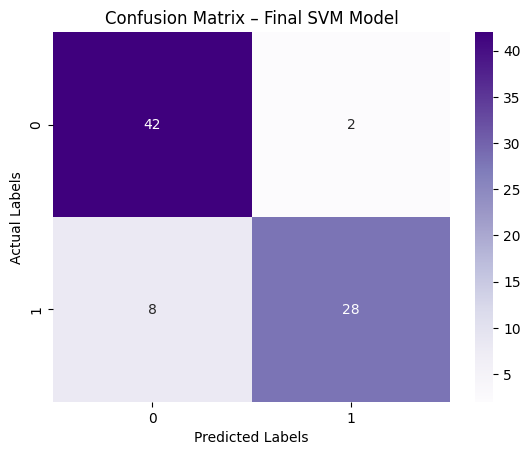

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix – Final SVM Model")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()


In [ ]:
import joblib, os

save_path = '/content/drive/My Drive/FinalYearProject/RetinalDieaseFYP/models'
os.makedirs(save_path, exist_ok=True)

joblib.dump(svm_model, os.path.join(save_path, "svm_model_final.pkl"))
print("Final SVM model saved successfully to Google Drive!")


Final SVM model saved successfully to Google Drive!


Trained KNN with 100 images — Accuracy: 85.00%
Trained KNN with 200 images — Accuracy: 90.00%
Trained KNN with 400 images — Accuracy: 83.75%


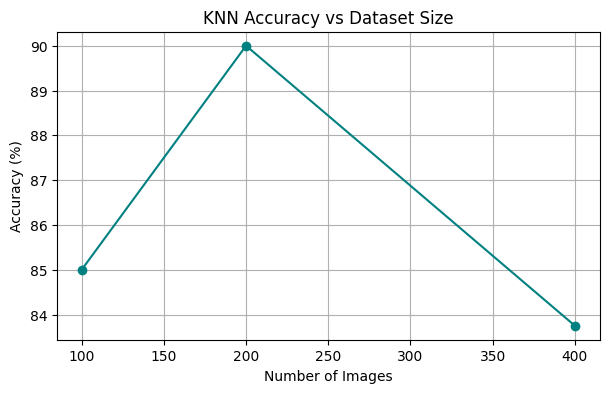

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

image_sizes = [100, 200, 400]
results_knn = {}

for n in image_sizes:
    X, y = load_images(num_per_class=n//2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_model.predict(X_test))

    results_knn[n] = acc
    print(f"Trained KNN with {n} images — Accuracy: {acc*100:.2f}%")

# Plot accuracy trend
plt.figure(figsize=(7,4))
plt.plot(list(results_knn.keys()), [v*100 for v in results_knn.values()], marker='o', color='teal')
plt.title("KNN Accuracy vs Dataset Size")
plt.xlabel("Number of Images")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()


In [ ]:
import joblib, os

save_path = '/content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/models'
os.makedirs(save_path, exist_ok=True)
joblib.dump(knn_model, os.path.join(save_path, "knn_model_final.pkl"))
print("KNN model saved successfully to Google Drive!")


KNN model saved successfully to Google Drive!


Trained Random Forest with 100 images — Accuracy: 85.00%
Trained Random Forest with 200 images — Accuracy: 95.00%
Trained Random Forest with 400 images — Accuracy: 88.75%


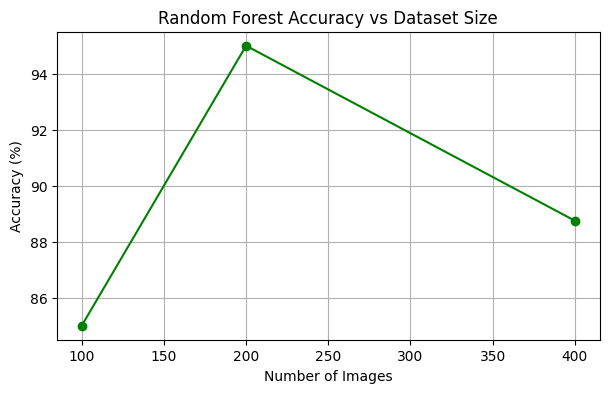

In [ ]:
from sklearn.ensemble import RandomForestClassifier

image_sizes = [100, 200, 400]
results_rf = {}

for n in image_sizes:
    X, y = load_images(num_per_class=n//2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf_model.predict(X_test))

    results_rf[n] = acc
    print(f"Trained Random Forest with {n} images — Accuracy: {acc*100:.2f}%")

# Plot accuracy trend
plt.figure(figsize=(7,4))
plt.plot(list(results_rf.keys()), [v*100 for v in results_rf.values()], marker='o', color='green')
plt.title("Random Forest Accuracy vs Dataset Size")
plt.xlabel("Number of Images")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()


In [ ]:
save_path = '/content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/models'
os.makedirs(save_path, exist_ok=True)
joblib.dump(rf_model, os.path.join(save_path, "rf_model_final.pkl"))
print("Random Forest model saved")

Random Forest model saved


Trained Logistic Regression with 100 images — Accuracy: 85.00%
Trained Logistic Regression with 200 images — Accuracy: 92.50%
Trained Logistic Regression with 400 images — Accuracy: 91.25%


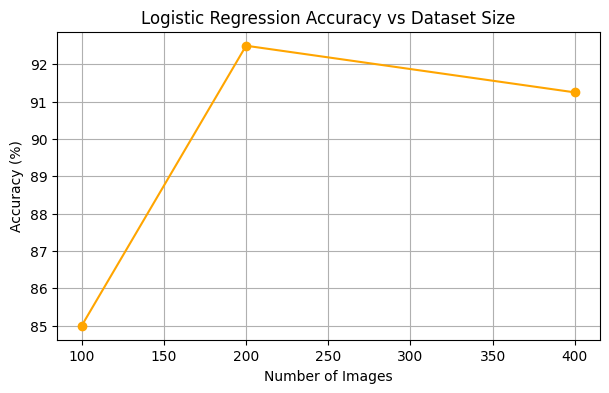

In [ ]:
from sklearn.linear_model import LogisticRegression

image_sizes = [100, 200, 400]
results_lr = {}

for n in image_sizes:
    X, y = load_images(num_per_class=n//2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    log_model = LogisticRegression(max_iter=500, random_state=42)
    log_model.fit(X_train, y_train)
    acc = accuracy_score(y_test, log_model.predict(X_test))

    results_lr[n] = acc
    print(f"Trained Logistic Regression with {n} images — Accuracy: {acc*100:.2f}%")

# Plot accuracy trend
plt.figure(figsize=(7,4))
plt.plot(list(results_lr.keys()), [v*100 for v in results_lr.values()], marker='o', color='orange')
plt.title("Logistic Regression Accuracy vs Dataset Size")
plt.xlabel("Number of Images")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()


In [ ]:
save_path = '/content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/models'
os.makedirs(save_path, exist_ok=True)
joblib.dump(log_model, os.path.join(save_path, "logistic_model_final.pkl"))
print("Logistic Regression saved")


Logistic Regression saved
